# Interactive demo — close evaluation for two sound-hard spheres

**What this is.**  A plane wave $e^{ikz}$ hits two sound-hard spheres on the
$z$-axis.  The field is represented by double-layer potentials,
$u = e^{ikz} + \sum_i D_i[u_i]$, and the Galerkin block system for the traces
$u_i$ is solved with the off-diagonal coupling blocks assembled by the
**close-evaluation quadrature** of Carvalho, Khatri & Kim: the integration grid
on the source sphere is rotated so its pole sits at the point closest to the
target, and an exactly-integrable plane wave matching the density there is
subtracted and restored analytically
(Khatri, Kim, Cortez & Carvalho, *J. Comput. Phys.* 2020; Carvalho, *Math.
Comput. Appl.* 2021).

**What the demo shows.**  Layer potentials are nearly singular when the
evaluation point is close to the integration surface, so *naive* product-Gauss
quadrature develops an $O(1)$ error halo hugging each sphere — invisible in a
pretty field plot, fatal for anything quantitative in a narrow gap.  The
subtraction quadrature removes the halo entirely, at the same quadrature size.
Drag the gap down to $10^{-2}$ and recompute: the error maps in row 2 are the
whole story.

**Why the error maps are honest.**  For spheres the double-layer potential of
each basis density has a closed form via the multipole identity
$D[\tilde P_n](x) = i k^2 a^2\, j_n'(ka)\, h_n^{(1)}(k|x-C|)\, \tilde
P_n(\cos\gamma)$, giving pointwise ground truth at *any* distance from the
surface.  That is what makes a true error map possible here.  For general
(non-spherical) shapes no such identity exists — only the quadrature method
survives, which is precisely why it matters.

In [1]:
import time
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt

from offdiag_bie import (SphereQuadrature, ptilde, dlp_column_exact,
                         dlp_column_naive, dlp_column_subtract, coupling_block)

## Solver (as validated in `Nspheres_sound_hard.ipynb`)

Diagonal blocks $a_i^2\,\mathrm{diag}(\lambda_n(a_i))$ with
$\lambda_n(a) = -i(ka)^2 j_n(ka)\,{h_n^{(1)}}'(ka)$, off-diagonal blocks
$-\langle \tilde P_m, D_j[\tilde P_n]\rangle_{\partial B_i}$ assembled with the
close-evaluation quadrature, right-hand side
$b^i_n = a_i^2\, e^{ikz_i}\, i^n \sqrt{4\pi(2n+1)}\, j_n(ka_i)$.

In [2]:
def lambda_n(N, k, a):
    n = np.arange(N)
    jn = sp.spherical_jn(n, k * a)
    dhn = sp.spherical_jn(n, k * a, derivative=True) \
        + 1j * sp.spherical_yn(n, k * a, derivative=True)
    return -1j * (k * a)**2 * jn * dhn


def rhs_block(N, k, a, z):
    n = np.arange(N)
    return a**2 * np.exp(1j * k * z) * (1j)**n * np.sqrt(4 * np.pi * (2 * n + 1)) \
        * sp.spherical_jn(n, k * a)


def solve(N, k, radii, zs, quad, method='subtract'):
    Ns = len(radii)
    A = np.zeros((Ns * N, Ns * N), dtype=complex)
    b = np.zeros(Ns * N, dtype=complex)
    for i, (ai, zi) in enumerate(zip(radii, zs)):
        A[i*N:(i+1)*N, i*N:(i+1)*N] = ai**2 * np.diag(lambda_n(N, k, ai))
        b[i*N:(i+1)*N] = rhs_block(N, k, ai, zi)
        Ci = np.array([0.0, 0.0, zi])
        for j, (aj, zj) in enumerate(zip(radii, zs)):
            if j != i:
                Cj = np.array([0.0, 0.0, zj])
                A[i*N:(i+1)*N, j*N:(j+1)*N] = -coupling_block(
                    N, k, aj, Cj, ai, Ci, quad, method=method)
    c = np.linalg.solve(A, b)
    return [c[i*N:(i+1)*N] for i in range(Ns)]

## Field evaluation

`scattered(...)` evaluates $\sum_i D_i[u_i](x)$ with a single quadrature method
everywhere (for the error maps), returning NaN inside the spheres.
`scattered_hybrid(...)` uses the subtraction quadrature in the near-surface
band and the fast exact columns elsewhere (for the field maps, as in
`Nspheres_sound_hard.ipynb`).

In [3]:
COLUMNS = {'naive': dlp_column_naive, 'subtract': dlp_column_subtract}


def scattered(pts, coeffs, N, k, radii, centers, quad, method):
    """sum_i D_i[u_i](x) with one quadrature method everywhere; NaN inside."""
    pts = np.atleast_2d(pts)
    u = np.zeros(len(pts), dtype=complex)
    for ix, x in enumerate(pts):
        if min(np.linalg.norm(x - C) - a for a, C in zip(radii, centers)) < 0:
            u[ix] = np.nan
            continue
        for ci, (a, C) in enumerate(zip(radii, centers)):
            if method == 'exact':
                col = dlp_column_exact(N, k, a, C, x)
            else:
                col = COLUMNS[method](N, k, a, C, x, quad)
            u[ix] += col @ coeffs[ci]
    return u


def scattered_hybrid(pts, coeffs, N, k, radii, centers, quad, band=0.5):
    """Subtraction quadrature within band*a of each surface, exact columns
    elsewhere; NaN inside the spheres."""
    pts = np.atleast_2d(pts)
    u = np.zeros(len(pts), dtype=complex)
    for ix, x in enumerate(pts):
        dists = [np.linalg.norm(x - C) - a for a, C in zip(radii, centers)]
        if min(dists) < 0:
            u[ix] = np.nan
            continue
        for ci, (a, C) in enumerate(zip(radii, centers)):
            if dists[ci] < band * a:
                col = dlp_column_subtract(N, k, a, C, x, quad)
            else:
                col = dlp_column_exact(N, k, a, C, x)
            u[ix] += col @ coeffs[ci]
    return u

## The demo function

Solves the system and produces three rows of plots:

1. **Total field** $\operatorname{Re}u$ and $|u|$ in the $x$–$z$ plane
   (subtraction quadrature near the surfaces, exact columns elsewhere).
2. **The selling plot** — $\log_{10}$ absolute error of the scattered-field
   evaluation against the exact multipole columns, naive product-Gauss on the
   left, CKK + subtraction on the right, same color scale.  Both use the same
   solved coefficients; only the evaluation quadrature differs.
3. $|u|$ along the $z$-axis (full line and a zoom into the gap), computed
   three ways: the naive curve breaks away from the exact one as the axis
   approaches each surface, while the subtraction curve overlays it.

In [4]:
def recompute(a1=1.0, a2=1.0, gap=0.05, k=2.0, Nbasis=14, Nq=32,
              fine=(150, 180), coarse=(90, 110)):
    """Solve the two-sphere problem and draw the three plot rows."""
    if gap <= 0:
        print(f"Spheres overlap (gap = {gap:.3f} <= 0) -- "
              "increase the gap and recompute.")
        return
    z1, z2 = 0.0, a1 + gap + a2
    radii, zs = [a1, a2], [z1, z2]
    centers = [np.array([0.0, 0.0, z]) for z in zs]
    quad = SphereQuadrature(Nq)
    print(f"a1={a1:g}, a2={a2:g}, gap={gap:g}, k={k:g}, "
          f"Nbasis={Nbasis}, Nq={Nq}  (sphere 2 center at z={z2:g})")

    # ---- solve the block system with close-evaluation coupling blocks ----
    t0 = time.time()
    coeffs = solve(Nbasis, k, radii, zs, quad, method='subtract')
    t_solve = time.time() - t0
    print(f"block system ({2 * Nbasis} unknowns) solved in {t_solve:.2f} s")

    # ---- plot window ----
    amax = max(a1, a2)
    xlim = (-(amax + 1.6), amax + 1.6)
    zlim = (z1 - a1 - 1.6, z2 + a2 + 1.6)

    # ---- row 1: total field on the fine grid (hybrid evaluation) ----
    t0 = time.time()
    nxf, nzf = fine
    Xf, Zf = np.meshgrid(np.linspace(*xlim, nxf), np.linspace(*zlim, nzf))
    pts_f = np.column_stack([Xf.ravel(), np.zeros(Xf.size), Zf.ravel()])
    U = (np.exp(1j * k * pts_f[:, 2])
         + scattered_hybrid(pts_f, coeffs, Nbasis, k, radii, centers, quad)
         ).reshape(nzf, nxf)
    t_field = time.time() - t0
    print(f"total field on {nxf} x {nzf} grid in {t_field:.1f} s")

    # ---- row 2: error maps on the coarse grid, all three methods ----
    t0 = time.time()
    nxc, nzc = coarse
    Xc, Zc = np.meshgrid(np.linspace(*xlim, nxc), np.linspace(*zlim, nzc))
    pts_c = np.column_stack([Xc.ravel(), np.zeros(Xc.size), Zc.ravel()])
    args = (coeffs, Nbasis, k, radii, centers, quad)
    u_exact = scattered(pts_c, *args, 'exact')
    err_nai = np.abs(scattered(pts_c, *args, 'naive') - u_exact)
    err_sub = np.abs(scattered(pts_c, *args, 'subtract') - u_exact)
    t_err = time.time() - t0
    print(f"error maps (naive/subtract/exact) on {nxc} x {nzc} grid in {t_err:.1f} s")

    # near-surface band: within 0.2*a_i of sphere i's surface (outside)
    rel = np.column_stack(
        [(np.linalg.norm(pts_c - C, axis=1) - a) / a
         for a, C in zip(radii, centers)])
    dist = np.min(rel, axis=1)
    in_band = (dist >= 0) & (dist < 0.2)
    max_nai = np.nanmax(err_nai[in_band])
    max_sub = np.nanmax(err_sub[in_band])
    print(f"max |error| within 0.2a of a surface: naive {max_nai:.1e}, "
          f"subtraction {max_sub:.1e}")

    # ---- row 3: |u| on the z-axis, three ways (full line + gap zoom) ----
    t0 = time.time()
    zline = np.linspace(zlim[0], zlim[1], 500)
    zgap = np.linspace(z1 + a1 + 0.02 * gap, z2 - a2 - 0.02 * gap, 80)
    lines, gaplines = {}, {}
    for m in ('naive', 'subtract', 'exact'):
        for zv, store in ((zline, lines), (zgap, gaplines)):
            p = np.column_stack([np.zeros((len(zv), 2)), zv])
            store[m] = np.abs(np.exp(1j * k * zv) + scattered(p, *args, m))
    t_line = time.time() - t0
    print(f"axis lines ({len(zline)} + {len(zgap)} points, three methods) "
          f"in {t_line:.1f} s")
    print(f"total: {t_solve + t_field + t_err + t_line:.1f} s")

    # ================= figure =================
    fig = plt.figure(figsize=(11.5, 15.5))
    gs = fig.add_gridspec(3, 2, height_ratios=[1.05, 1.05, 0.55], hspace=0.28)

    def outlines(ax):
        for a, z in zip(radii, zs):
            ax.add_patch(plt.Circle((0, z), a, fill=False, color='k', lw=1.2))
        ax.set_aspect('equal')
        ax.set_xlabel('$x$')
        ax.set_ylabel('$z$')

    # row 1 -- total field
    for j, (F, cmap, ttl, vmin, vmax) in enumerate([
            (np.real(U), 'RdBu_r', 'Re $u$ (total field)', -2.2, 2.2),
            (np.abs(U), 'viridis', '$|u|$ (total field)', 0.0, 2.2)]):
        ax = fig.add_subplot(gs[0, j])
        pc = ax.pcolormesh(Xf, Zf, F, cmap=cmap, vmin=vmin, vmax=vmax,
                           shading='gouraud', rasterized=True)
        outlines(ax)
        ax.set_title(ttl)
        fig.colorbar(pc, ax=ax, shrink=0.9)

    # row 2 -- the selling plot: log10 error maps, same scale
    for j, (err, ttl, mx) in enumerate([
            (err_nai, 'naive product-Gauss quadrature', max_nai),
            (err_sub, 'CKK rotated grid + subtraction', max_sub)]):
        ax = fig.add_subplot(gs[1, j])
        pc = ax.pcolormesh(Xc, Zc, np.log10(np.maximum(err, 1e-17)
                                            ).reshape(nzc, nxc),
                           cmap='magma', vmin=-16, vmax=0, rasterized=True)
        outlines(ax)
        ax.set_title(f'$\\log_{{10}}$ |scattered-field error|\n{ttl}')
        ax.text(0.03, 0.02, f'max error near surfaces: {mx:.1e}',
                transform=ax.transAxes, fontsize=10, color='k', va='bottom',
                bbox=dict(facecolor='w', alpha=0.85, edgecolor='none',
                          boxstyle='round,pad=0.3'))
        fig.colorbar(pc, ax=ax, shrink=0.9)

    # row 3 -- |u| on the z-axis: full line (left) and gap zoom (right)
    def three_lines(ax, zv, curves):
        ax.plot(zv, curves['exact'], color='k', ls=':', lw=2.5,
                label='exact columns')
        ax.plot(zv, curves['naive'], color='#d95f02', ls='--', lw=1.8,
                label='naive quadrature')
        ax.plot(zv, curves['subtract'], color='#1b6ca8', lw=1.8,
                label='CKK + subtraction')
        ax.set_xlabel('$z$ (on the axis)')
        ax.set_ylabel('$|u|$')
        ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[2, 0])
    three_lines(ax, zline, lines)
    finite = lines['exact'][np.isfinite(lines['exact'])]
    ax.set_ylim(0, 1.35 * np.max(finite))
    for a, z in zip(radii, zs):
        ax.axvspan(z - a, z + a, color='0.85', zorder=0)
    ax.set_xlim(zlim)
    ax.set_title('$|u|$ along the $z$-axis (gray = inside the spheres)')
    ax.legend(loc='upper left', framealpha=0.9, fontsize=9)

    ax = fig.add_subplot(gs[2, 1])
    three_lines(ax, zgap, gaplines)
    lo = min(np.min(gaplines['exact']), np.min(gaplines['naive']))
    hi = max(np.max(gaplines['exact']), np.max(gaplines['naive']))
    ax.set_ylim(max(0.0, lo - 0.15 * (hi - lo + 1e-3)),
                hi + 0.15 * (hi - lo + 1e-3))
    ax.set_xlim(z1 + a1, z2 - a2)
    ax.set_title(f'zoom: through the gap (width {gap:g})')
    ax.legend(loc='best', framealpha=0.9, fontsize=9)

    fig.suptitle(f'Two sound-hard spheres, $k={k:g}$, gap $={gap:g}$: '
                 'close evaluation vs naive quadrature', y=0.995, fontsize=13)
    plt.show()

## Static run (default parameters)

The same function the widget button calls, run directly so the committed
notebook shows all three plot rows without a live kernel.  Gap $= 0.05$ —
small enough that the naive halos of the two spheres merge across the gap.

a1=1, a2=1, gap=0.05, k=2, Nbasis=14, Nq=32  (sphere 2 center at z=2.05)
block system (28 unknowns) solved in 0.06 s


total field on 150 x 180 grid in 8.5 s


error maps (naive/subtract/exact) on 90 x 110 grid in 25.9 s
max |error| within 0.2a of a surface: naive 4.5e+00, subtraction 2.2e-03


axis lines (500 + 80 points, three methods) in 0.9 s
total: 35.5 s


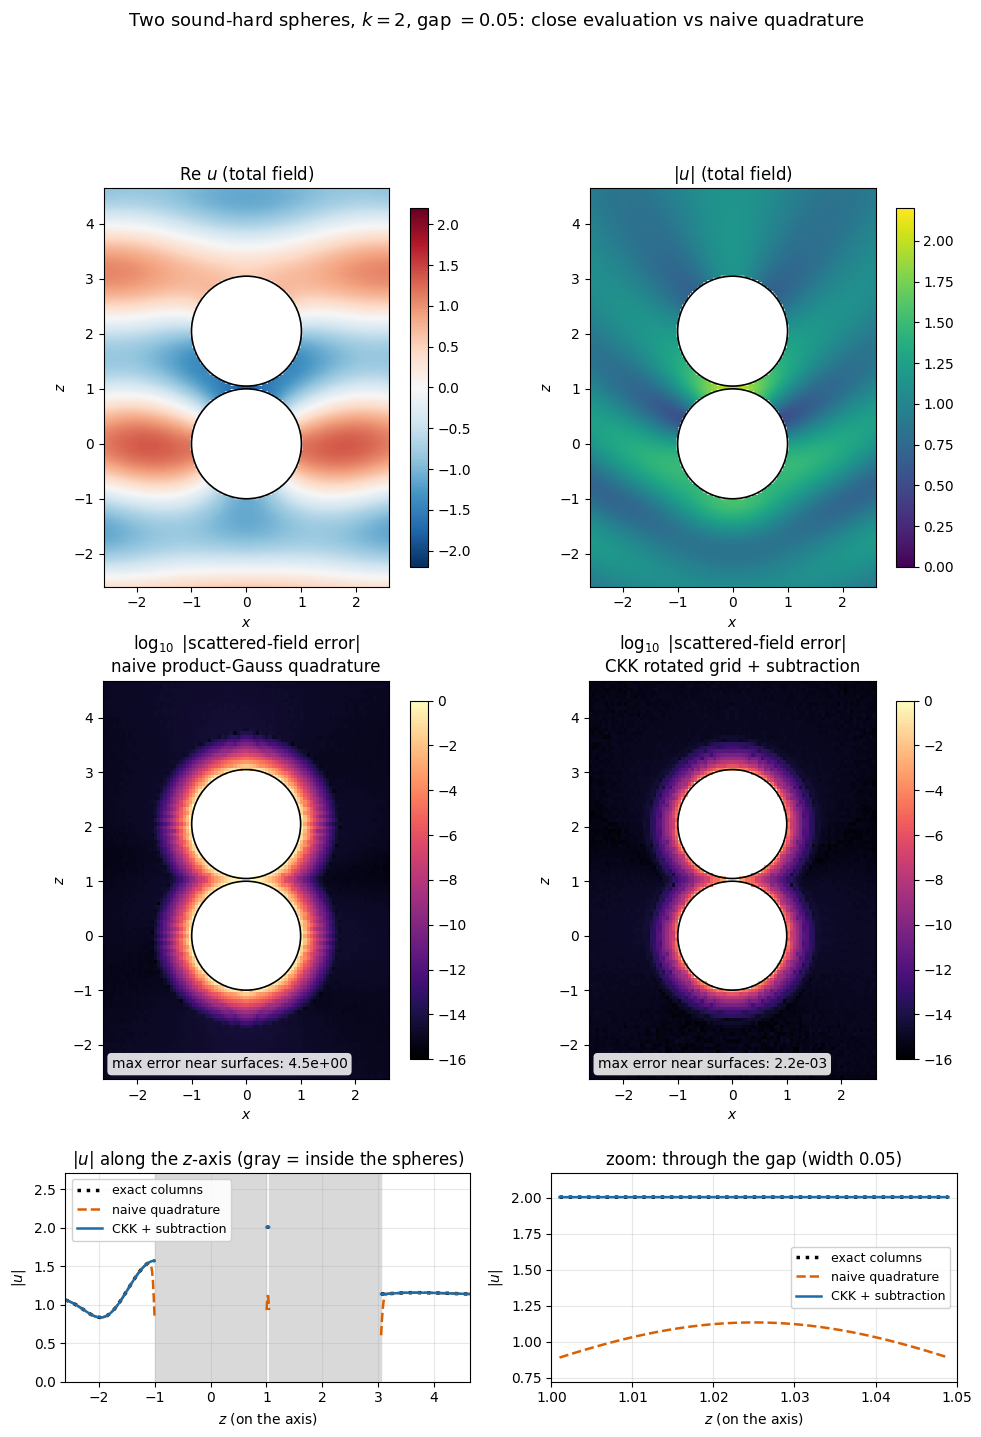

wall time: 35.9 s


In [5]:
t0 = time.time()
recompute(a1=1.0, a2=1.0, gap=0.05, k=2.0, Nbasis=14, Nq=32)
print(f'wall time: {time.time() - t0:.1f} s')

## Live control panel

Move the sliders, then press **Recompute** (solves run only on click; expect
roughly half a minute per run at the default grid sizes).  The gap slider is
logarithmic — push it down to $10^{-2}$ to watch the naive halo swallow the
gap while the subtraction map stays at the quadrature floor.

In [6]:
import ipywidgets as w

s_a1 = w.FloatSlider(value=1.0, min=0.3, max=1.5, step=0.05,
                     description='radius $a_1$', readout_format='.2f')
s_a2 = w.FloatSlider(value=1.0, min=0.3, max=1.5, step=0.05,
                     description='radius $a_2$', readout_format='.2f')
s_gap = w.FloatLogSlider(value=0.05, base=10, min=-2, max=np.log10(4.0),
                         step=0.05, description='gap', readout_format='.3f')
s_k = w.FloatSlider(value=2.0, min=0.5, max=5.0, step=0.1,
                    description='wavenumber $k$')
s_Nb = w.IntSlider(value=14, min=8, max=20, description='$N_{basis}$')
s_Nq = w.IntSlider(value=32, min=12, max=48, step=4, description='$N_q$')
btn = w.Button(description='Recompute', button_style='primary', icon='refresh')
out = w.Output()


def on_click(_):
    with out:
        out.clear_output(wait=True)
        recompute(a1=s_a1.value, a2=s_a2.value, gap=s_gap.value,
                  k=s_k.value, Nbasis=s_Nb.value, Nq=s_Nq.value)


btn.on_click(on_click)
panel = w.VBox([w.HBox([s_a1, s_a2, s_gap]),
                w.HBox([s_k, s_Nb, s_Nq]),
                btn, out])
display(panel)